## Final model

In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "/Users/vaibhavi/Dynamoedge/ML models/Work Order:Ticket forecasting model/argentinal_full_tkt.csv"

data = pd.read_csv(DATA_PATH)
data['CONTACT_CREATE_DT'] = pd.to_datetime(data['CONTACT_CREATE_DT'])

wo = data[data['HAS_WORK_ORDER'] == 'Y'].copy()
wo['date'] = wo['CONTACT_CREATE_DT'].dt.date
daily = wo.groupby('date').size()
daily.index = pd.to_datetime(daily.index)

full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
daily = daily.reindex(full_idx, fill_value=0)

print(f"✓ Data loaded: {len(daily)} days")
print(f"  Mean/day: {daily.mean():.1f}")

✓ Data loaded: 638 days
  Mean/day: 3.1


In [3]:
train = daily.iloc[:-30]
test = daily.iloc[-30:]

print(f"Train: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

Train: 608 days (2024-12-02 to 2026-08-01)
Test:  30 days (2026-08-02 to 2026-08-31)


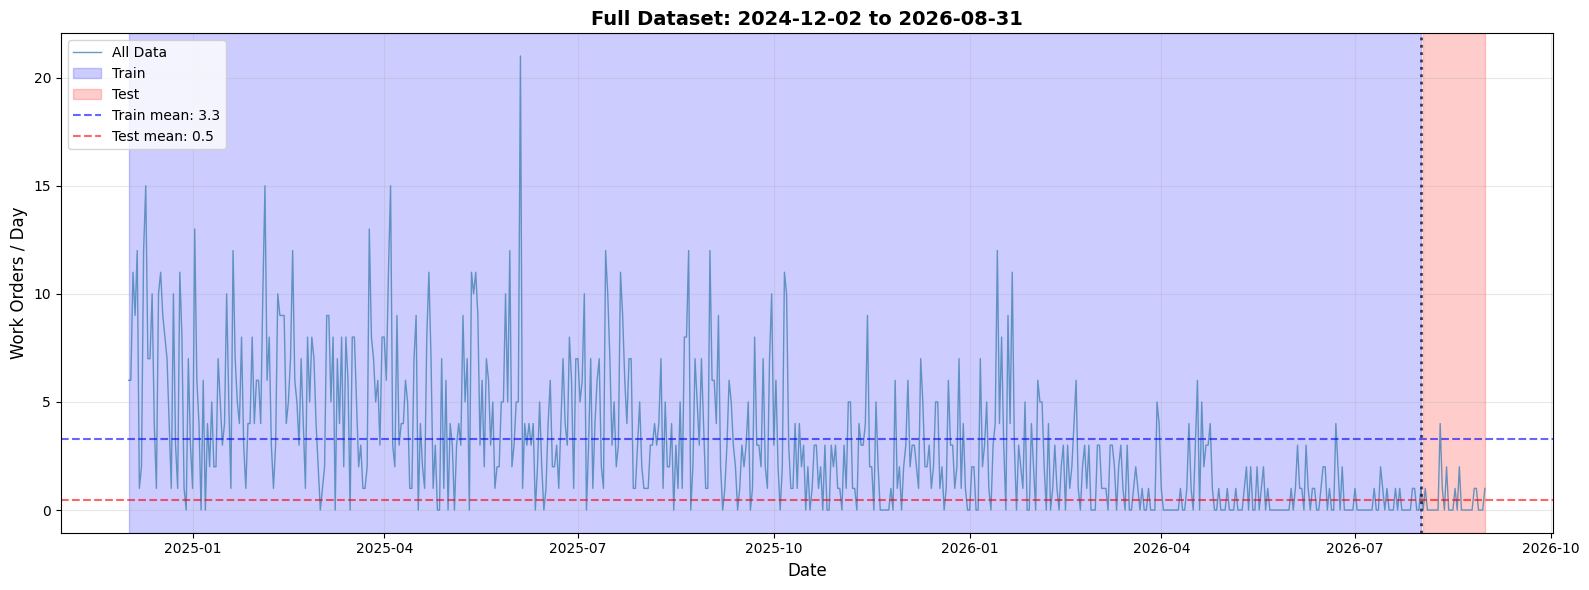

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily.index, daily.values, label='All Data', color='steelblue', linewidth=1, alpha=0.8)
ax.axvspan(train.index[0], train.index[-1], alpha=0.2, color='blue', label='Train')
ax.axvspan(test.index[0], test.index[-1], alpha=0.2, color='red', label='Test')
ax.axhline(train.mean(), color='blue', linestyle='--', alpha=0.6, linewidth=1.5,
           label=f'Train mean: {train.mean():.1f}')
ax.axhline(test.mean(), color='red', linestyle='--', alpha=0.6, linewidth=1.5,
           label=f'Test mean: {test.mean():.1f}')
ax.axvline(train.index[-1], color='black', linestyle=':', alpha=0.7, linewidth=2)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Work Orders / Day', fontsize=12)
ax.set_title(f'Full Dataset: {daily.index.min().date()} to {daily.index.max().date()}',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('full_data_history_argentina.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
best_order = (1, 1, 0)
best_sorder = (0, 1, 1, 7)

model = SARIMAX(train, order=best_order, seasonal_order=best_sorder,
                 enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False)

forecast = fit.get_forecast(steps=len(test))
pred = forecast.predicted_mean.clip(lower=0)
conf = forecast.conf_int(alpha=0.05).clip(lower=0)

comparison_ar = pd.DataFrame({
    'date': test.index,
    'actual': test.values,
    'forecast': pred.values.round(1),
    'lower_95': conf.iloc[:, 0].values.round(1),
    'upper_95': conf.iloc[:, 1].values.round(1),
})
comparison_ar['error'] = comparison_ar['actual'] - comparison_ar['forecast']

mae = np.mean(np.abs(comparison_ar['error']))
rmse = np.sqrt(np.mean(comparison_ar['error']**2))
nonzero = comparison_ar['actual'] != 0
mape = np.mean(np.abs((comparison_ar.loc[nonzero, 'actual'] - comparison_ar.loc[nonzero, 'forecast'])
                       / comparison_ar.loc[nonzero, 'actual'])) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"Min error: {comparison_ar['error'].min()}")
print(f"Max error: {comparison_ar['error'].max()}")

MAE:  0.72
RMSE: 0.90
MAPE: 44.44%
Min error: -1.5
Max error: 2.4


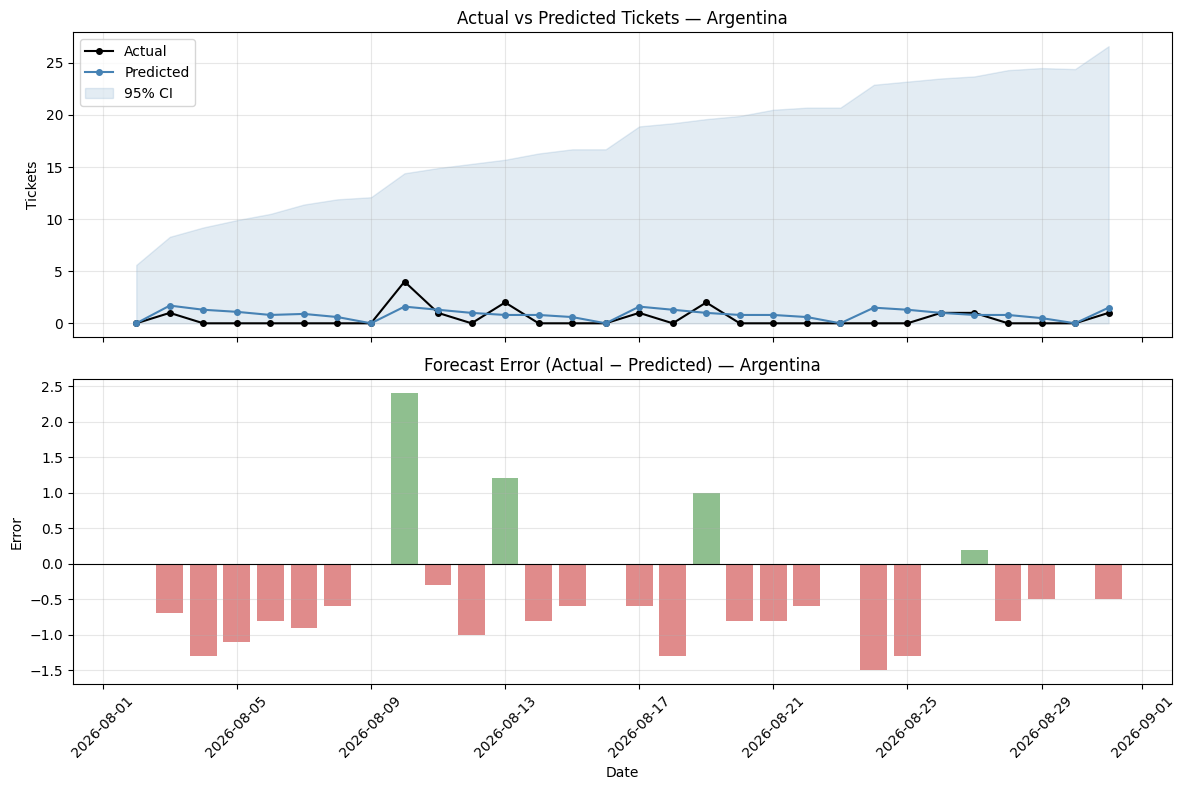

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(comparison_ar['date'], comparison_ar['actual'],
         label='Actual', color='black', marker='o', linewidth=1.5, markersize=4)
ax1.plot(comparison_ar['date'], comparison_ar['forecast'],
         label='Predicted', color='steelblue', marker='o', linewidth=1.5, markersize=4)
ax1.fill_between(comparison_ar['date'], comparison_ar['lower_95'], comparison_ar['upper_95'],
                  color='steelblue', alpha=0.15, label='95% CI')
ax1.set_ylabel('Tickets')
ax1.set_title('Actual vs Predicted Tickets — Argentina')
ax1.legend()
ax1.grid(True, alpha=0.3)

colors = ['#8fbf8f' if e >= 0 else '#e08b8b' for e in comparison_ar['error']]
ax2.bar(comparison_ar['date'], comparison_ar['error'], color=colors)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Error')
ax2.set_xlabel('Date')
ax2.set_title('Forecast Error (Actual − Predicted) — Argentina')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('actual_vs_predicted_error_argentina.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
print(f"Zero days: {(train == 0).mean()*100:.1f}%")
print(f"Value counts:\n{train.value_counts().sort_index()}")

Zero days: 23.0%
Value counts:
0     140
1     102
2      70
3      75
4      47
5      39
6      30
7      32
8      21
9      15
10     12
11     10
12      9
13      2
15      3
21      1
Name: count, dtype: int64


In [8]:
mean_val = train.mean()
var_val = train.var()
print(f"Mean: {mean_val:.2f}")
print(f"Variance: {var_val:.2f}")
print(f"Variance/Mean ratio: {var_val/mean_val:.2f}")

Mean: 3.27
Variance: 10.97
Variance/Mean ratio: 3.36


In [9]:
fit.save("sarimax_argentina_model.pkl")